### Loading Dataframe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_exam_scores.csv', header=0)
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


### Getting general Info

In [2]:
print(pd.DataFrame(df.info()))
print(pd.DataFrame(df.describe()))
print("Df Columns:", list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB
Empty DataFrame
Columns: []
Index: []
       hours_studied  sleep_hours  attendance_percent  previous_scores  \
count     200.000000   200.000000          200.000000       200.000000   
mean        6.325500     6.622000           74.830000        66.800000   
std         3.227317     1.497138           14.249905        15.663869   
min         1.000000     4.000000           50.300000        40.000000   
25%         3.500000     5.300000 

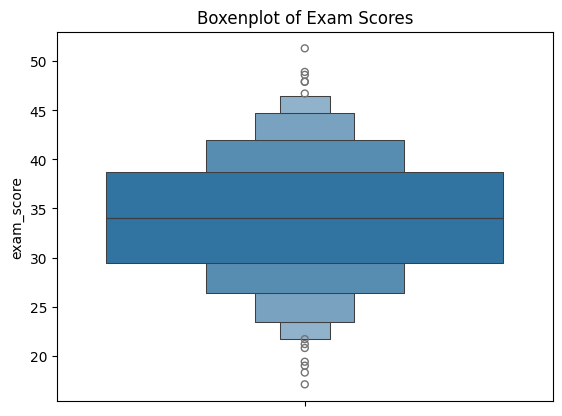

Max Score: 51.3 Min Score: 17.1
Mean Score: 33.955
Median Score: 34.05
Mode: 36.1


In [3]:
sns.boxenplot(data=df["exam_score"])
plt.title("Boxenplot of Exam Scores")
plt.show()
print("Max Score:", df["exam_score"].max(), "Min Score:", df["exam_score"].min())
print("Mean Score:", df["exam_score"].mean())
print("Median Score:", df["exam_score"].median())
print("Mode:", df["exam_score"].mode()[0])


# Correlation Matrix and Heatmap

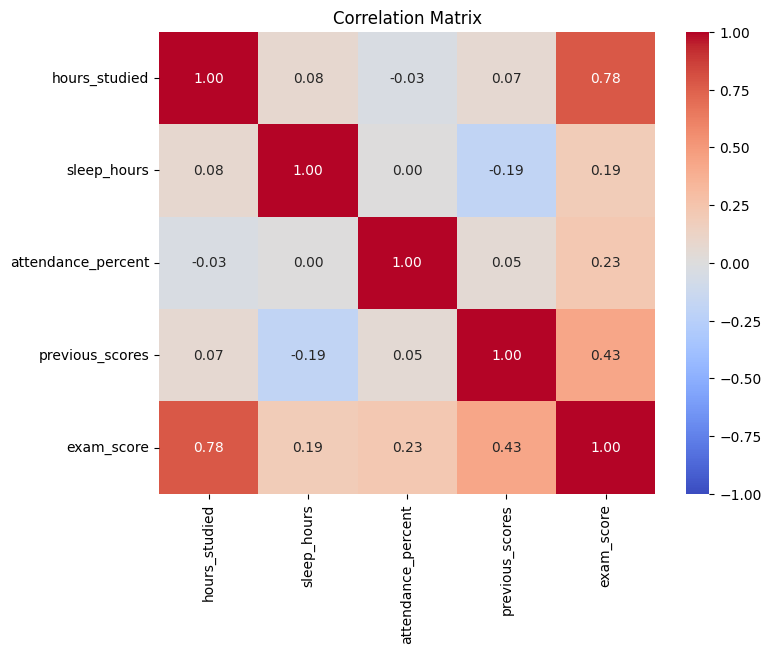

In [4]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

From the heatmap we've seen that every feature is useful to explain the final grade; they have not much correlation so i will use them all.

### Splitting Features and Target

I'm not relying on training and evaluation dataset for the simple reason that the dataset is very small so to limit the overfitting  
we're gonna use a regularized model and use crossvalidation as a overfitting evaluator.


In [5]:
features_df = df[['hours_studied', 'sleep_hours', 'attendance_percent','previous_scores']]
target_df = df['exam_score']

### Training the model

I've chosen Ridge to limit overfitting, and since there are not many features all worth of attention

### Why Ridge Model?

Works well with few features, and limits our overfitting

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# Define pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('ridge_regression', Ridge())
])

# Define parameter grid for alpha
param_grid = {
    'ridge_regression__alpha': [0.01, 0.1, 1, 10, 100, 200, 500, 1000]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Use negative MSE for regression
    n_jobs=-1  # Use all cores
)

# Fit to data
grid_search.fit(features_df, target_df)

# Best model and alpha
best_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_['ridge_regression__alpha']
best_score = -grid_search.best_score_  # Convert back to positive MSE

# Predictions and metrics
predictions = best_model.predict(features_df)
mse = mean_squared_error(target_df, predictions)

print("Best Alpha:", best_alpha)
print("Best CV MSE:", best_score)
print("R2 Score:", best_model.score(features_df, target_df))
print("Mean Squared Error:", mse)
print("Average RMSE:", np.sqrt(mse))




Best Alpha: 0.1
Best CV MSE: 7.7271646147833355
R2 Score: 0.8413969880782954
Mean Squared Error: 7.274719684243484
Average RMSE: 2.697168827538144


### Cross Validation

I'm working on a small dataset so it has no sense to rely on Training and Evaluation set overfitting check, so our overfitting index will be cross validation

In [7]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(ridge_model, features_df, target_df, cv=cv, scoring="r2")
mse_scores = cross_val_score(ridge_model, features_df, target_df, cv=cv, scoring="neg_mean_squared_error")
print("Average R²:", np.mean(r2_scores))   # % of variance explained How well your model captures the signal
print("Average MSE:", -np.mean(mse_scores)) # Average Error 
print("Average RMSE:", np.sqrt(-np.mean(mse_scores))) # Root Mean Squared Error Error in original units (e.g., dollars, cm)


NameError: name 'ridge_model' is not defined

### Results :

Considered everything we've said i consider my results appropriate and truthful, the model is likely not overfitted and there is no data leakage:

### -----In the end the model is Able to Explain a solid 83% of the final grade-------

## OutLayers

Text(0.5, 1.0, 'Q-Q Plot of Residuals')

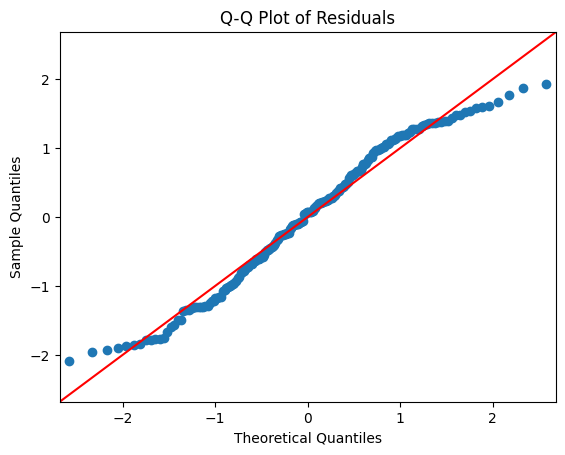

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

residuals = target_df - predictions
sm.qqplot(residuals, line ='45', fit=True)
plt.title("Q-Q Plot of Residuals")

In [ ]:
# Access the fitted Ridge model inside the pipeline
ridge_step = pipeline.named_steps['ridge_regression']

# Get the coefficients
coefficients = ridge_step.coef_

# Optionally, get the intercept
intercept = ridge_step.intercept_

# Print them
print("Intercept:", intercept)
print("Coefficients:", coefficients)

coef_df = pd.DataFrame({
    'Feature': features_df.columns,
    'Coefficient': coefficients
})
print(coef_df.sort_values(by='Coefficient', ascending=False))

Intercept: 16.768752547703485
Coefficients: [16.21126066  4.47764738  5.07639733  9.20263851]
              Feature  Coefficient
0       hours_studied    16.211261
3     previous_scores     9.202639
2  attendance_percent     5.076397
1         sleep_hours     4.477647
